In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from statsmodels.stats.multitest import fdrcorrection

import torch

from transformers import AutoModelForCausalLM, GPT2Tokenizer, logging

logging.set_verbosity_error()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
# Import model and tokenizer
model_name = 'gpt2-large'

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)

num_layers = model.config.n_layer

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 1280)
    (wpe): Embedding(1024, 1280)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-35): 36 x GPT2Block(
        (ln_1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=3840, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=1280)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=5120, nx=1280)
          (c_proj): Conv1D(nf=1280, nx=5120)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=1280, out_features=50257, bias=False)
)

# Implant hooks

In [ ]:
# Function to implant hooks
activations = {}

def implant_attn_hooks(layeri):
  def hook(module, input, output):
    activations[f'attn_{layeri}'] = output.detach()
    return None
  return hook

def implant_mlp_hooks(layeri):
  def hook(module, input, output):
    activations[f'mlp_{layeri}'] = output.detach()
    return None
  return hook

if "hook_attn" in globals():
  for h in hook_attn:
    h.remove()

if "hook_mlp" in globals():
  for h in hook_mlp:
    h.remove()

hook_attn, hook_mlp = [], []

for layeri in range(num_layers):
  hook_attn.append(model.transformer.h[layeri].attn.c_proj.register_forward_hook(implant_attn_hooks(layeri)))
  hook_mlp.append(model.transformer.h[layeri].mlp.c_proj.register_forward_hook(implant_mlp_hooks(layeri)))



# Import text

In [ ]:
# https://en.wikipedia.org/wiki/Friedrich_Nietzsche
text = "Nietzsche was a widely influential German philosopher. He began his career as a classical philologist, turning to philosophy early in his academic career. In 1869, aged 24, Nietzsche became the youngest professor to hold the Chair of Classical Philology at the University of Basel. Plagued by health problems for most of his life, he resigned from the university in 1879, after which he completed much of his core writing in the following decade. Nietzsche's work spans philosophical polemics, poetry, cultural criticism, and fiction while displaying a fondness for aphorism and irony. Prominent elements of his philosophy include his radical critique of truth in favour of perspectivism; a genealogical critique of religion and Christian morality and a related theory of master–slave morality; the aesthetic affirmation of life in response to both the 'death of God' and the profound crisis of nihilism; the notion of Apollonian and Dionysian forces; and a characterisation of the human subject as the expression of competing wills, collectively understood as the will to power. He also developed influential concepts such as the Übermensch and his doctrine of eternal return. In his later work, he became increasingly preoccupied with the creative powers of the individual to overcome cultural and moral mores in pursuit of new values and aesthetic health. His body of work touched a wide range of topics, including art, philology, history, music, religion, tragedy, culture, and science, and drew inspiration from Greek tragedy as well as figures such as Zoroaster, Arthur Schopenhauer, Ralph Waldo Emerson, Richard Wagner, Fyodor Dostoevsky, and Johann Wolfgang von Goethe."

token_ids = tokenizer.encode(text, return_tensors='pt').to(device)

# Forward Pass the tokens through the model

In [ ]:
with torch.no_grad():
  output = model(token_ids, output_hidden_states=True)

In [ ]:
activations.keys()

dict_keys(['attn_0', 'mlp_0', 'attn_1', 'mlp_1', 'attn_2', 'mlp_2', 'attn_3', 'mlp_3', 'attn_4', 'mlp_4', 'attn_5', 'mlp_5', 'attn_6', 'mlp_6', 'attn_7', 'mlp_7', 'attn_8', 'mlp_8', 'attn_9', 'mlp_9', 'attn_10', 'mlp_10', 'attn_11', 'mlp_11', 'attn_12', 'mlp_12', 'attn_13', 'mlp_13', 'attn_14', 'mlp_14', 'attn_15', 'mlp_15', 'attn_16', 'mlp_16', 'attn_17', 'mlp_17', 'attn_18', 'mlp_18', 'attn_19', 'mlp_19', 'attn_20', 'mlp_20', 'attn_21', 'mlp_21', 'attn_22', 'mlp_22', 'attn_23', 'mlp_23', 'attn_24', 'mlp_24', 'attn_25', 'mlp_25', 'attn_26', 'mlp_26', 'attn_27', 'mlp_27', 'attn_28', 'mlp_28', 'attn_29', 'mlp_29', 'attn_30', 'mlp_30', 'attn_31', 'mlp_31', 'attn_32', 'mlp_32', 'attn_33', 'mlp_33', 'attn_34', 'mlp_34', 'attn_35', 'mlp_35'])

In [ ]:
activations['attn_0'].shape, activations['mlp_0'].shape, output.hidden_states[-1].shape, len(output.hidden_states)

(torch.Size([1, 342, 1280]),
 torch.Size([1, 342, 1280]),
 torch.Size([1, 342, 1280]),
 37)

# Cosine Similarities between attention and mlp vector adjustments

In [ ]:
cossims = np.zeros((num_layers, len(token_ids[0])))

for layeri in range(num_layers):
  for toki in range(len(token_ids[0])):
    acts_attn = activations[f'attn_{layeri}'][0, toki, :].unsqueeze(0)
    acts_mlp = activations[f'mlp_{layeri}'][0, toki, :].unsqueeze(0)
    cossims[layeri, toki] = torch.cosine_similarity(acts_attn, acts_mlp, dim=1)

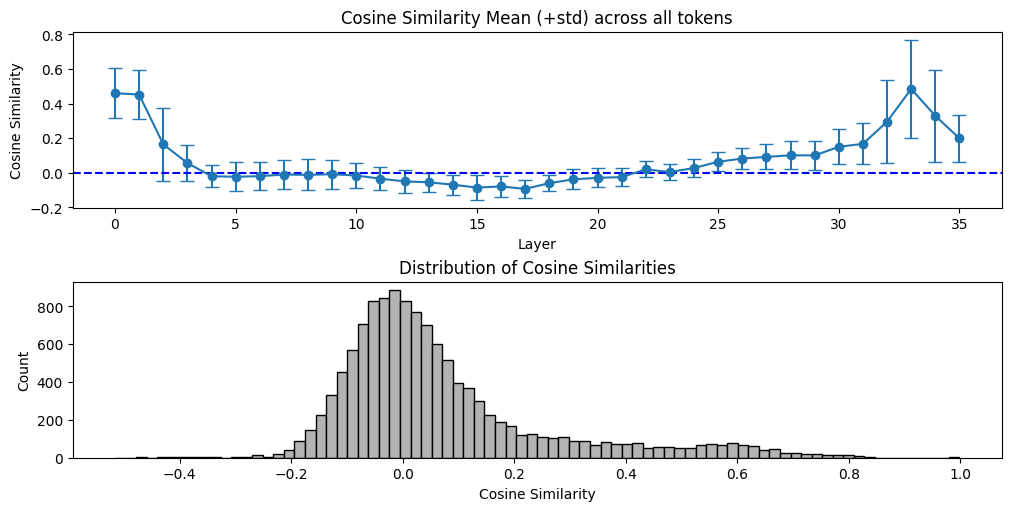

In [ ]:
# Plot
plt.figure(figsize=(10,5), layout='constrained')
plt.subplot(2,1,1)
plt.errorbar(range(num_layers), cossims.mean(axis=1), yerr=cossims.std(axis=1), marker = 'o', capsize=5)
plt.axhline(y=0, c='b', linestyle='--')
plt.xlabel('Layer')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity Mean (+std) across all tokens')

plt.subplot(2,1,2)
plt.hist(cossims.flatten(), bins=80, color=[.7,.7,.7],edgecolor='k',lw=.5)
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title('Distribution of Cosine Similarities')

plt.show()

# Path lengths for each token venctor relative to previous layer for:
- Attention Layers
- MLP Layers
- Hidden Layers

In [ ]:
attn_path = np.zeros((num_layers, len(token_ids[0])))
mlp_path = np.zeros((num_layers, len(token_ids[0])))
hidden_path = np.zeros((num_layers, len(token_ids[0])))

for layeri in range(1,num_layers):
  for toki in range(len(token_ids[0])):
    attn_path[layeri, toki] = torch.linalg.norm(activations[f'attn_{layeri}'][0, toki, :] - activations[f'attn_{layeri-1}'][0, toki, :])
    mlp_path[layeri, toki] = torch.linalg.norm(activations[f'mlp_{layeri}'][0, toki, :] - activations[f'mlp_{layeri-1}'][0, toki, :])
    hidden_path[layeri, toki] = torch.linalg.norm(output.hidden_states[layeri+1][0, toki, :] - output.hidden_states[layeri][0,toki,:])

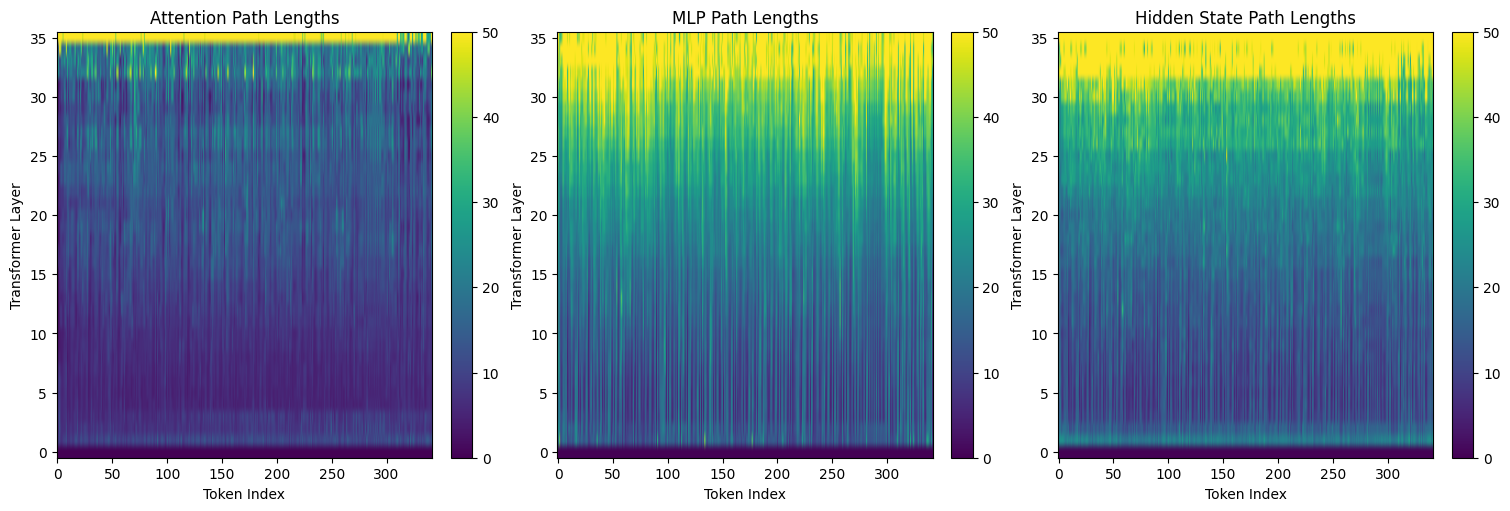

In [ ]:
# Plot
plt.figure(figsize=(15,5), layout='constrained')
plt.subplot(1,3,1)
plt.imshow(attn_path, vmin=0, vmax=50, cmap='viridis', aspect='auto', origin='lower')
plt.xlabel('Token Index')
plt.ylabel('Transformer Layer')
plt.title('Attention Path Lengths')
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(mlp_path, vmin=0, vmax=50, cmap='viridis', aspect='auto', origin='lower')
plt.xlabel('Token Index')
plt.ylabel('Transformer Layer')
plt.title('MLP Path Lengths')
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(hidden_path, vmin=0, vmax=50, cmap='viridis', aspect='auto', origin='lower')
plt.xlabel('Token Index')
plt.ylabel('Transformer Layer')
plt.title('Hidden State Path Lengths')
plt.colorbar()

plt.show()

# Correlation of adjustments and hidden states

In [58]:
r_values = np.zeros((num_layers, 2))
p_values = np.zeros((num_layers, 2))

for layeri in range(1,num_layers):

  # Derive Pearson correlation and p-value for attention adjustments
  r = pearsonr(attn_path[layeri, :], hidden_path[layeri, :]) # include first token
  # r = pearsonr(attn_path[layeri, 1:], hidden_path[layeri, 1:]) # skip first token
  r_values[layeri,0] = r.statistic
  p_values[layeri,0] = r.pvalue

  # Derive Pearson correlation and p-value for mlp adjustments
  r = pearsonr(mlp_path[layeri, :], hidden_path[layeri, :]) # include first token
  # r = pearsonr(mlp_path[layeri, 1:], hidden_path[layeri, 1:]) # skip first token
  r_values[layeri,1] = r.statistic
  p_values[layeri,1] = r.pvalue

In [59]:
# FDR (False Delivery Rate) corrections
sig_attn = fdrcorrection(p_values[:,0], alpha=0.05, method='indep')[0]
sig_mlp = fdrcorrection(p_values[:,1], alpha=0.05, method='indep')[0]

In [60]:
np.where(sig_attn)[0].shape, r_values[sig_attn,1].shape

((30,), (30,))

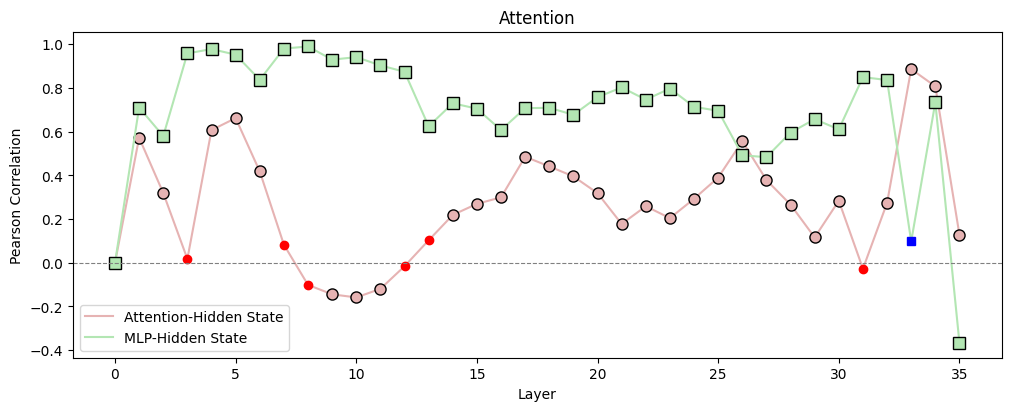

In [61]:
# Visualize
plt.figure(figsize=(10,4), layout='constrained')
plt.plot(r_values[:,0], color=[.9,.7,.7], label='Attention-Hidden State')
plt.plot(np.where(sig_attn)[0],r_values[sig_attn,0], 'ko', mfc=[.9,.7,.7], ms=8)
plt.plot(np.where(~sig_attn)[0],r_values[~sig_attn,0], 'ro', ms=6)

plt.plot(r_values[:,1], color=[.7,.9,.7], label='MLP-Hidden State')
plt.plot(np.where(sig_mlp)[0],r_values[sig_mlp,1], 'ks', mfc=[.7,.9,.7], ms=8)
plt.plot(np.where(~sig_mlp)[0],r_values[~sig_mlp,1], 'bs', ms=6)

plt.axhline(0, ls='--', lw=.8, color='gray')

plt.xlabel('Layer')
plt.ylabel('Pearson Correlation')
plt.title('Attention')
plt.legend()



plt.show()

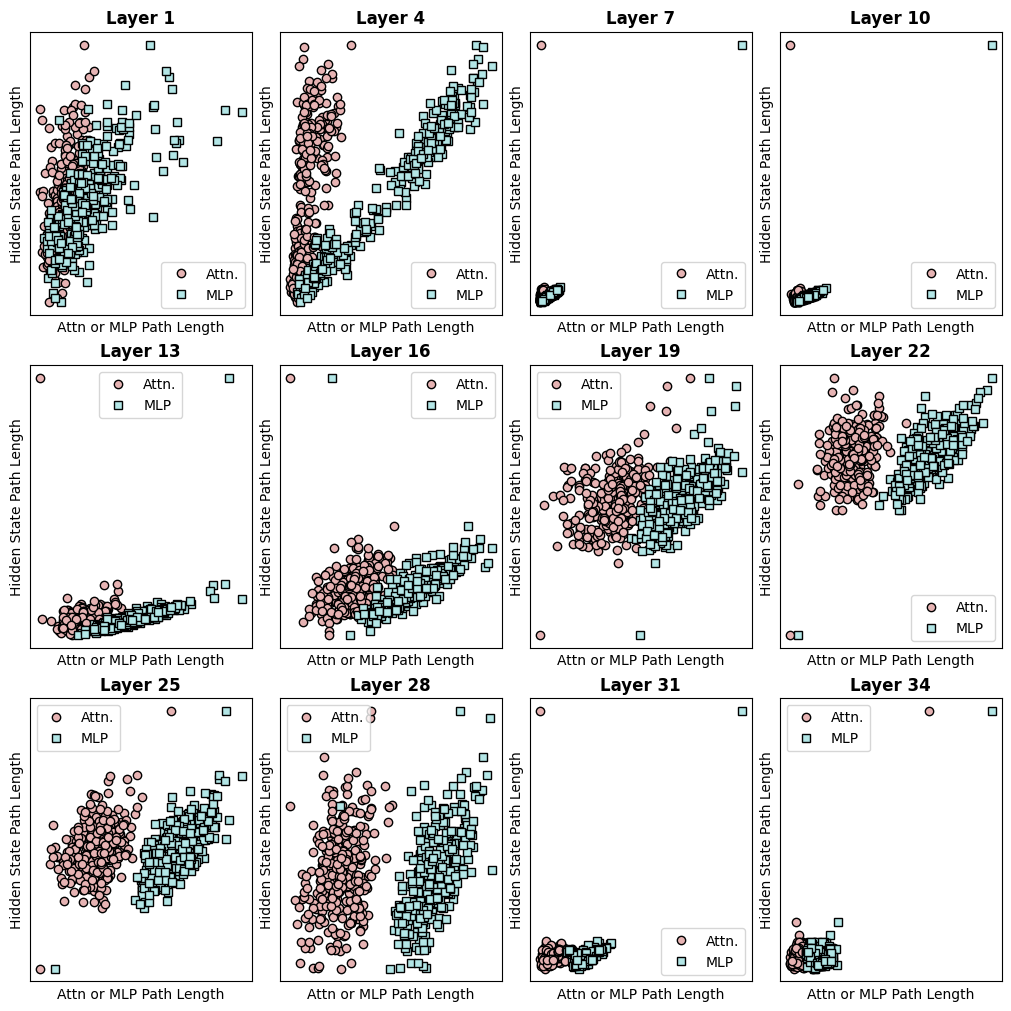

In [63]:
# Visualize the attention and MLP correlations with hidden state for all layers
fig = plt.figure(figsize=(10,10), layout='constrained')
axs = fig.subplots(3,4)

for i,ax in enumerate(axs.flatten()):

  layeri = i * 3 + 1
  # ax.plot(attn_path[layeri,1:], hidden_path[layeri,1:],'ko',mfc=[.9,.7,.7,1], label='Attn.')
  ax.plot(attn_path[layeri,:], hidden_path[layeri,:],'ko',mfc=[.9,.7,.7,1], label='Attn.')
  # ax.plot(mlp_path[layeri,1:], hidden_path[layeri,1:],'ks',mfc=[.7,.9,.9,1], label='MLP')
  ax.plot(mlp_path[layeri,:], hidden_path[layeri,:],'ks',mfc=[.7,.9,.9,1], label='MLP')

  ax.set_title(f'Layer {layeri}', fontweight='bold')
  ax.set_xticks([])
  ax.set_xlabel('Attn or MLP Path Length')
  ax.set_yticks([])
  ax.set_ylabel('Hidden State Path Length')

  ax.legend()

plt.show()
